Exploratory Data Analysis (EDA) is a technique to analyze data using some visual techniques. 
Perform a complete exploratory analysis on the Iris dataset.



Dataset load using pandas library and we have used the inbuit function i.e. read_csv. you have to just give the path of the csv file.


df.head() shows the first five rows of the dataset for a quick review.

In [25]:
import pandas as pd
df = pd.read_csv("dataset/Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [26]:
# use this command to install pandas on jupyter notebook for python3.x versions
# !pip3 install pandas

now, we have to check the rows and columns of the df. 

for this we can df.shape method and it shows the 150 rows and 6 columns in the dataset.

In [8]:
df.shape

(150, 6)

Check how many string and numeric datatypes variables in the dataset.

only Species column is of string data type and rest are numeric

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [31]:

"""
Return descriptive statistics for the DataFrame columns.

Computes count, mean, standard deviation, min, 25th percentile, median, 75th percentile, and max for numeric data by default.
Can also summarize non-numeric columns when include or exclude parameters are provided.
Useful for a quick overview of dataset distributions and missing values.
"""
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


Checking Missing Values

In [33]:
"counts the number of missing/null values in each column of the DataFrame."
df.isnull().sum()


Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Checking Duplicate Values

In [13]:
"Return DataFrame with duplicate rows removed."
data = df.drop_duplicates(subset="Species")
data

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
50,51,7.0,3.2,4.7,1.4,Iris-versicolor
100,101,6.3,3.3,6.0,2.5,Iris-virginica


In [35]:
"Series containing the frequency of each distinct row in the DataFrame."
df.value_counts("Species")

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

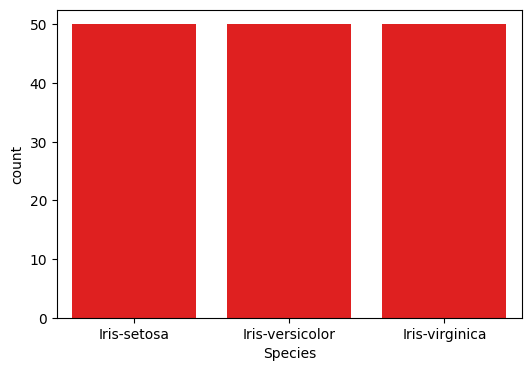

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.countplot(x='Species', data=df,color="red")
plt.show()

In [18]:
# !pip3 install seaborn
# !pip3 install matplotlib

Relationship between the sepal length and sepal width and also between petal length and petal width.

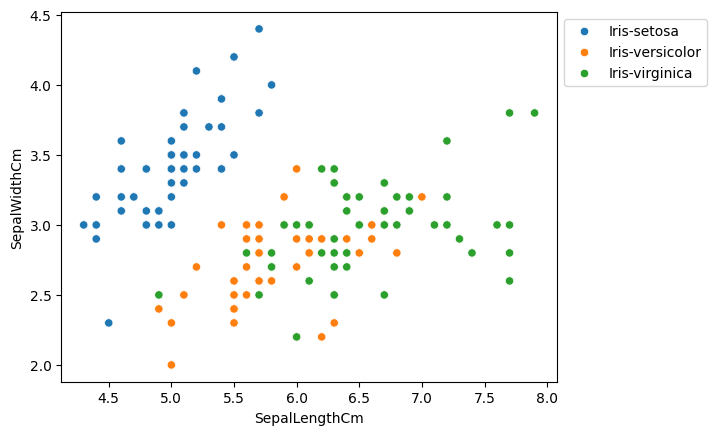

In [39]:

import seaborn as sns
import matplotlib.pyplot as plt


sns.scatterplot(x='SepalLengthCm', y='SepalWidthCm',
                hue='Species', data=df, )

plt.legend(bbox_to_anchor=(1, 1), loc=2)

plt.show()

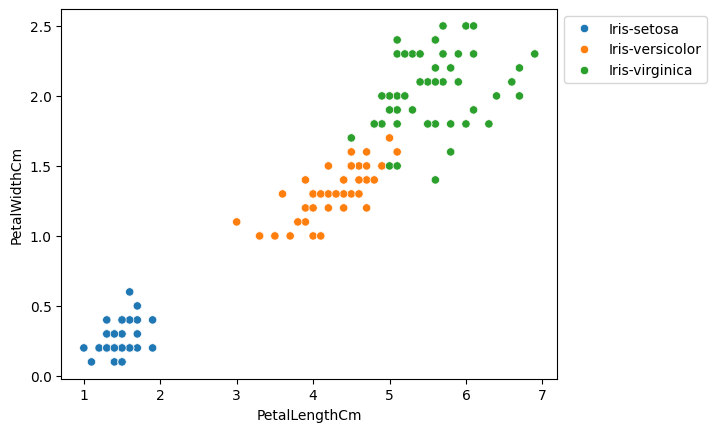

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.scatterplot(x='PetalLengthCm', y='PetalWidthCm',
                hue='Species', data=df, )

plt.legend(bbox_to_anchor=(1, 1), loc=2)

plt.show()

Let's plot all the column's relationships using a pairplot. It can be used for multivariate analysis.

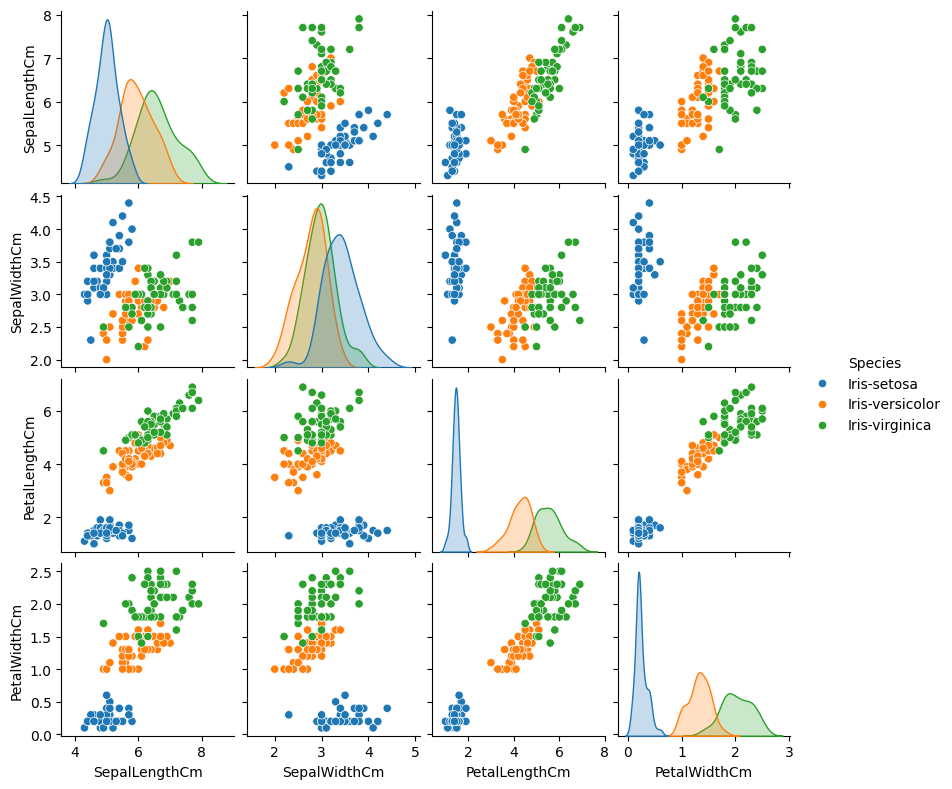

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.pairplot(df.drop(['Id'], axis = 1), 
             hue='Species', height=2)

Histograms
Histograms allow seeing the distribution of data for various columns. It can be used for uni as well as bi-variate analysis.

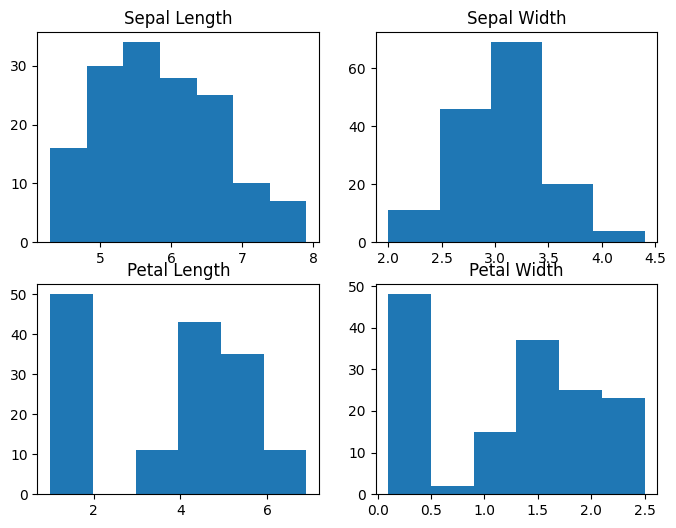

In [44]:
# importing packages
import seaborn as sns
import matplotlib.pyplot as plt


fig, axes = plt.subplots(2, 2, figsize=(8,6))

axes[0,0].set_title("Sepal Length")
axes[0,0].hist(df['SepalLengthCm'], bins=7)

axes[0,1].set_title("Sepal Width")
axes[0,1].hist(df['SepalWidthCm'], bins=5);

axes[1,0].set_title("Petal Length")
axes[1,0].hist(df['PetalLengthCm'], bins=6);

axes[1,1].set_title("Petal Width")
axes[1,1].hist(df['PetalWidthCm'], bins=6);

Handling Correlation
Pandas dataframe.corr() is used to find the pairwise correlation of all columns in the dataframe. Any NA values are automatically excluded. For any non-numeric data type columns in the dataframe it is ignored.

In [46]:
data.select_dtypes(include=['number']).corr(method='pearson')



,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Id,1.000000,0.624413,-0.654654,0.969909,0.999685
SepalLengthCm,0.624413,1.000000,-0.999226,0.795795,0.643817
SepalWidthCm,-0.654654,-0.999226,1.000000,-0.818999,-0.673417
PetalLengthCm,0.969909,0.795795,-0.818999,1.000000,0.975713
PetalWidthCm,0.999685,0.643817,-0.673417,0.975713,1.000000


Heatmaps
The heatmap is a data visualization technique that is used to analyze the dataset as colors in two dimensions. Basically, it shows a correlation between all numerical variables in the dataset.

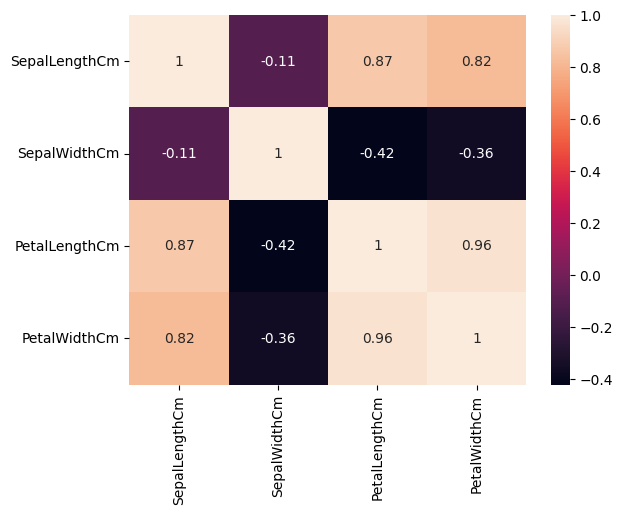

In [47]:
import seaborn as sns 
import matplotlib.pyplot as plt 


sns.heatmap(df.select_dtypes(include=['number']).corr(method='pearson').drop( 
['Id'], axis=1).drop(['Id'], axis=0), 
			annot = True); 

plt.show()



Box Plots
We can use boxplots to see how the categorical value os distributed with other numerical values.

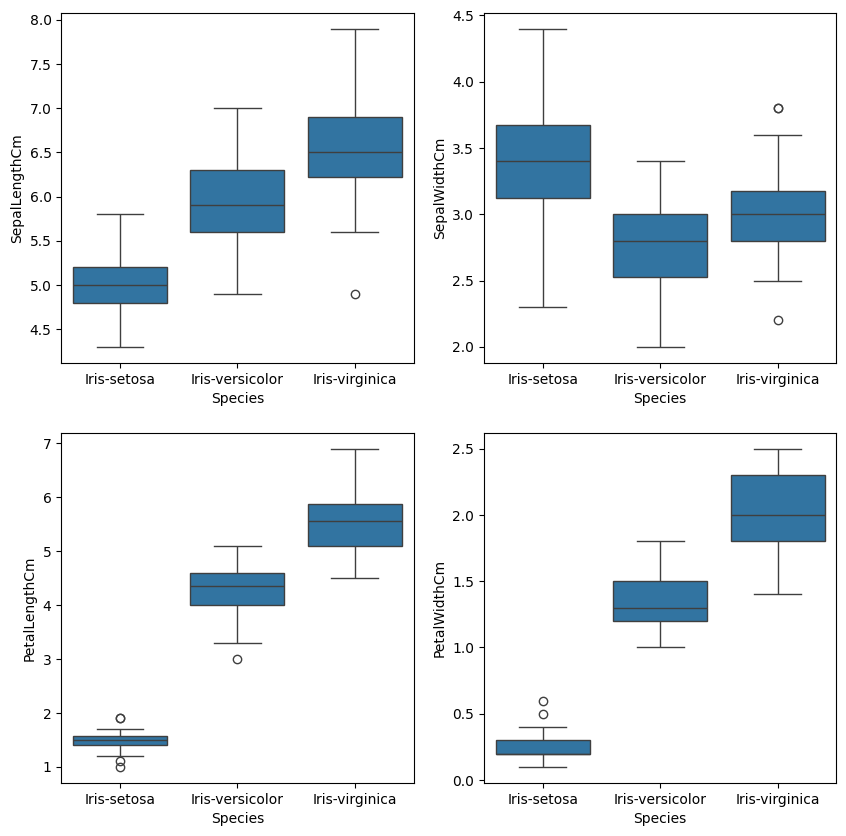

In [48]:
# importing packages
import seaborn as sns
import matplotlib.pyplot as plt

def graph(y):
    sns.boxplot(x="Species", y=y, data=df)

plt.figure(figsize=(10,10))
    
# Adding the subplot at the specified
# grid position
plt.subplot(221)
graph('SepalLengthCm')

plt.subplot(222)
graph('SepalWidthCm')

plt.subplot(223)
graph('PetalLengthCm')

plt.subplot(224)
graph('PetalWidthCm')

plt.show()

Handling Outliers


An Outlier is a data-item/object that deviates significantly from the rest of the (so-called normal)objects. They can be caused by measurement or execution errors. The analysis for outlier detection is referred to as outlier mining. There are many ways to detect the outliers, and the removal process is the data frame same as removing a data item from the panda’s dataframe.



<Axes: xlabel='SepalWidthCm'>

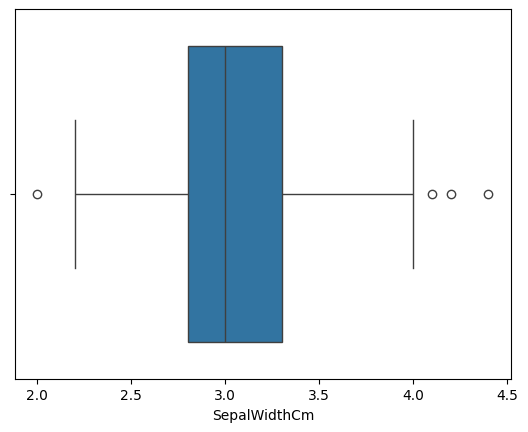

In [50]:
# importing packages
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
sns.boxplot(x='SepalWidthCm', data=df)

Removing Outliers


For removing the outlier, one must follow the same process of removing an entry from the dataset using its exact position in the dataset because in all the above methods of detecting the outliers end result is the list of all those data items that satisfy the outlier definition according to the method used.

We will detect the outliers using IQR and then we will remove them. We will also draw the boxplot to see if the outliers are removed or not.


Old Shape:  (150, 6)
New Shape:  (146, 6)


<Axes: xlabel='SepalWidthCm'>

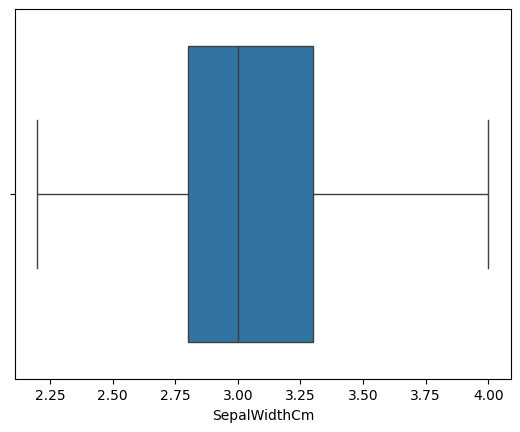

In [53]:
# Importing
import numpy as np

# Load the dataset 

# IQR 
Q1 = np.percentile(df['SepalWidthCm'], 25, 
				method = 'midpoint') 

Q3 = np.percentile(df['SepalWidthCm'], 75, 
				method = 'midpoint') 
IQR = Q3 - Q1 

print("Old Shape: ", df.shape) 

# Upper bound 
upper = np.where(df['SepalWidthCm'] >= (Q3+1.5*IQR)) 

# Lower bound 
lower = np.where(df['SepalWidthCm'] <= (Q1-1.5*IQR)) 

# Removing the Outliers 
df.drop(upper[0], inplace = True) 
df.drop(lower[0], inplace = True) 

print("New Shape: ", df.shape) 

sns.boxplot(x='SepalWidthCm', data=df)

